# Churn Modeling Dataset - DNN

## Overview
To predict whether a bank customer will leave the bank, close their account or continue as a customer.

**Target variable:** `Exited` — has the client subscribed to a term deposit? (`1` / `0`)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mohamedelalfy01/churn-modeling/Churn_Modelling.csv


# 1. Load Libraries 

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, cross_val_score

# Evaluation Metrics
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score, f1_score,roc_auc_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve 

# Neural Network 
from keras.models import Sequential
from keras.layers import Input, Dense , Activation, Dropout
from keras.optimizers import Adam ,RMSprop
from keras import  backend as K
from tensorflow.keras import regularizers
from keras.utils import to_categorical, plot_model


plt.style.use('dark_background')

# 2. Load Data

In [3]:
df = pd.read_csv('/kaggle/input/datasets/mohamedelalfy01/churn-modeling/Churn_Modelling.csv')

print(f"Shape: {df.shape}")

Shape: (10000, 14)


In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


# 3. Explore Data

### Data Information

In [6]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


### Delete non-relative data

In [8]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

### Check Missing Values

In [9]:
df.isnull().sum().sort_values(ascending=False)

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

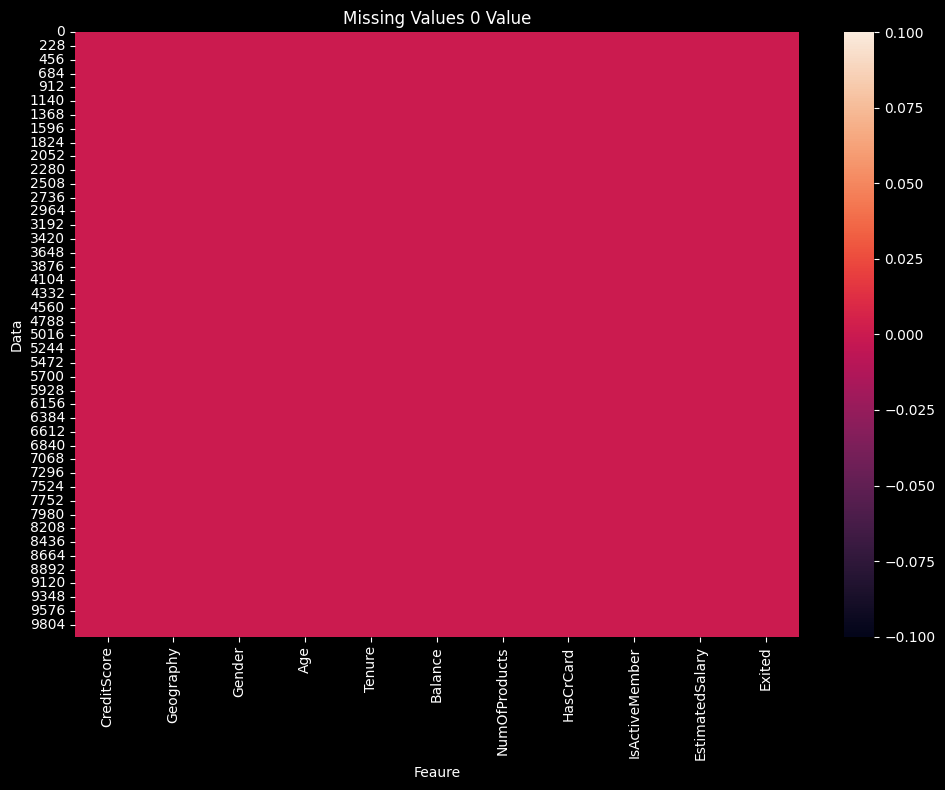

In [10]:
# Visualize Missing Data

plt.figure(figsize = (10,8))
sns.heatmap(df.isna(),cbar = True)

plt.xlabel("Feaure")
plt.ylabel("Data")
plt.title(f"Missing Values {df.isna().sum().sum()} Value")

plt.tight_layout()
plt.show()


### Check Duplicates

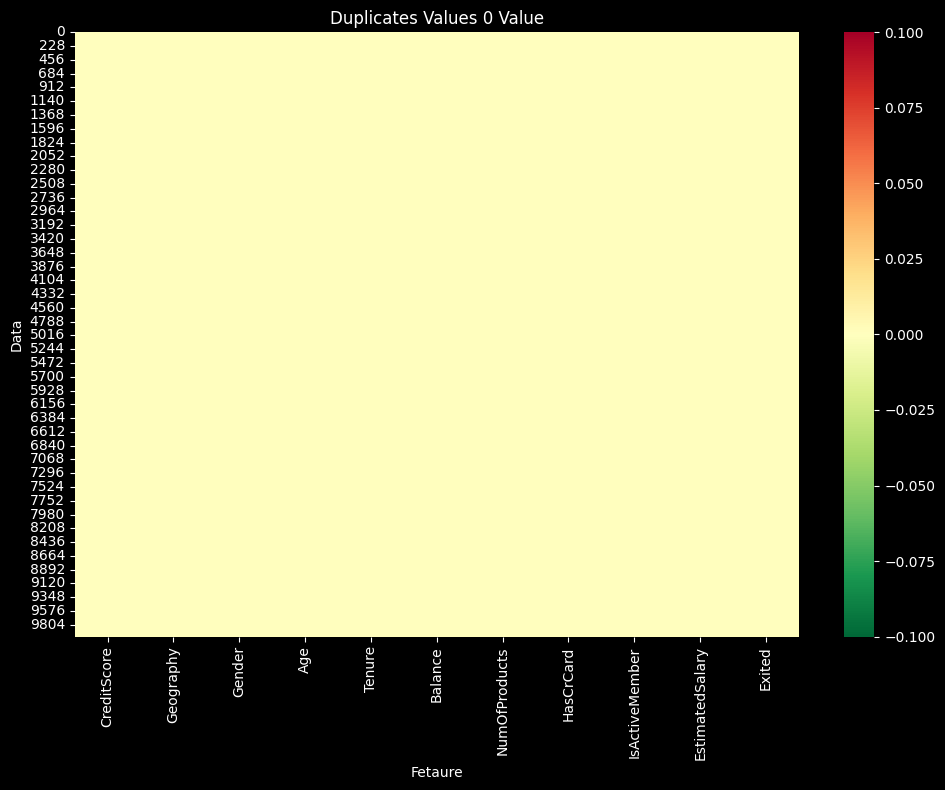

In [11]:
# Visualize Duplicated Data

plt.figure(figsize = (10,8))
duplicated_matrix = np.tile(df.duplicated().values.reshape(-1, 1), df.shape[1])
sns.heatmap(duplicated_matrix,cbar = True, cmap = 'RdYlGn_r', xticklabels=df.columns)

plt.xlabel("Fetaure")
plt.ylabel("Data")
plt.title(f"Duplicates Values {df.duplicated().sum()} Value")

plt.tight_layout()
plt.show()


### Check Target Distribution

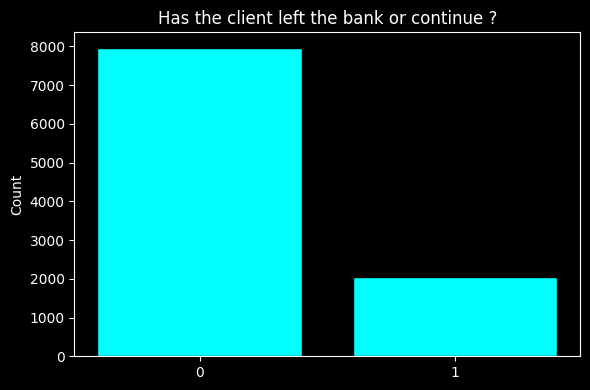



Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [12]:
plt.figure(figsize=(6, 4))
counts = df['Exited'].value_counts()

plt.bar(x = counts.index.astype(str), height=counts.values, color='cyan', edgecolor='black')


plt.title("Has the client left the bank or continue ?")
plt.ylabel("Count")
plt.xlabel("")

plt.tight_layout()
plt.show()

print("\n")
print(df["Exited"].value_counts(normalize=True) * 100)


### Check Feature ( Numerical - Catogorical)

In [13]:
num_col = df.select_dtypes(include = ["int64", "float64"]).columns
print(f"Number of this feature = {len(num_col)}")
print ("\n",num_col)

Number of this feature = 9

 Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


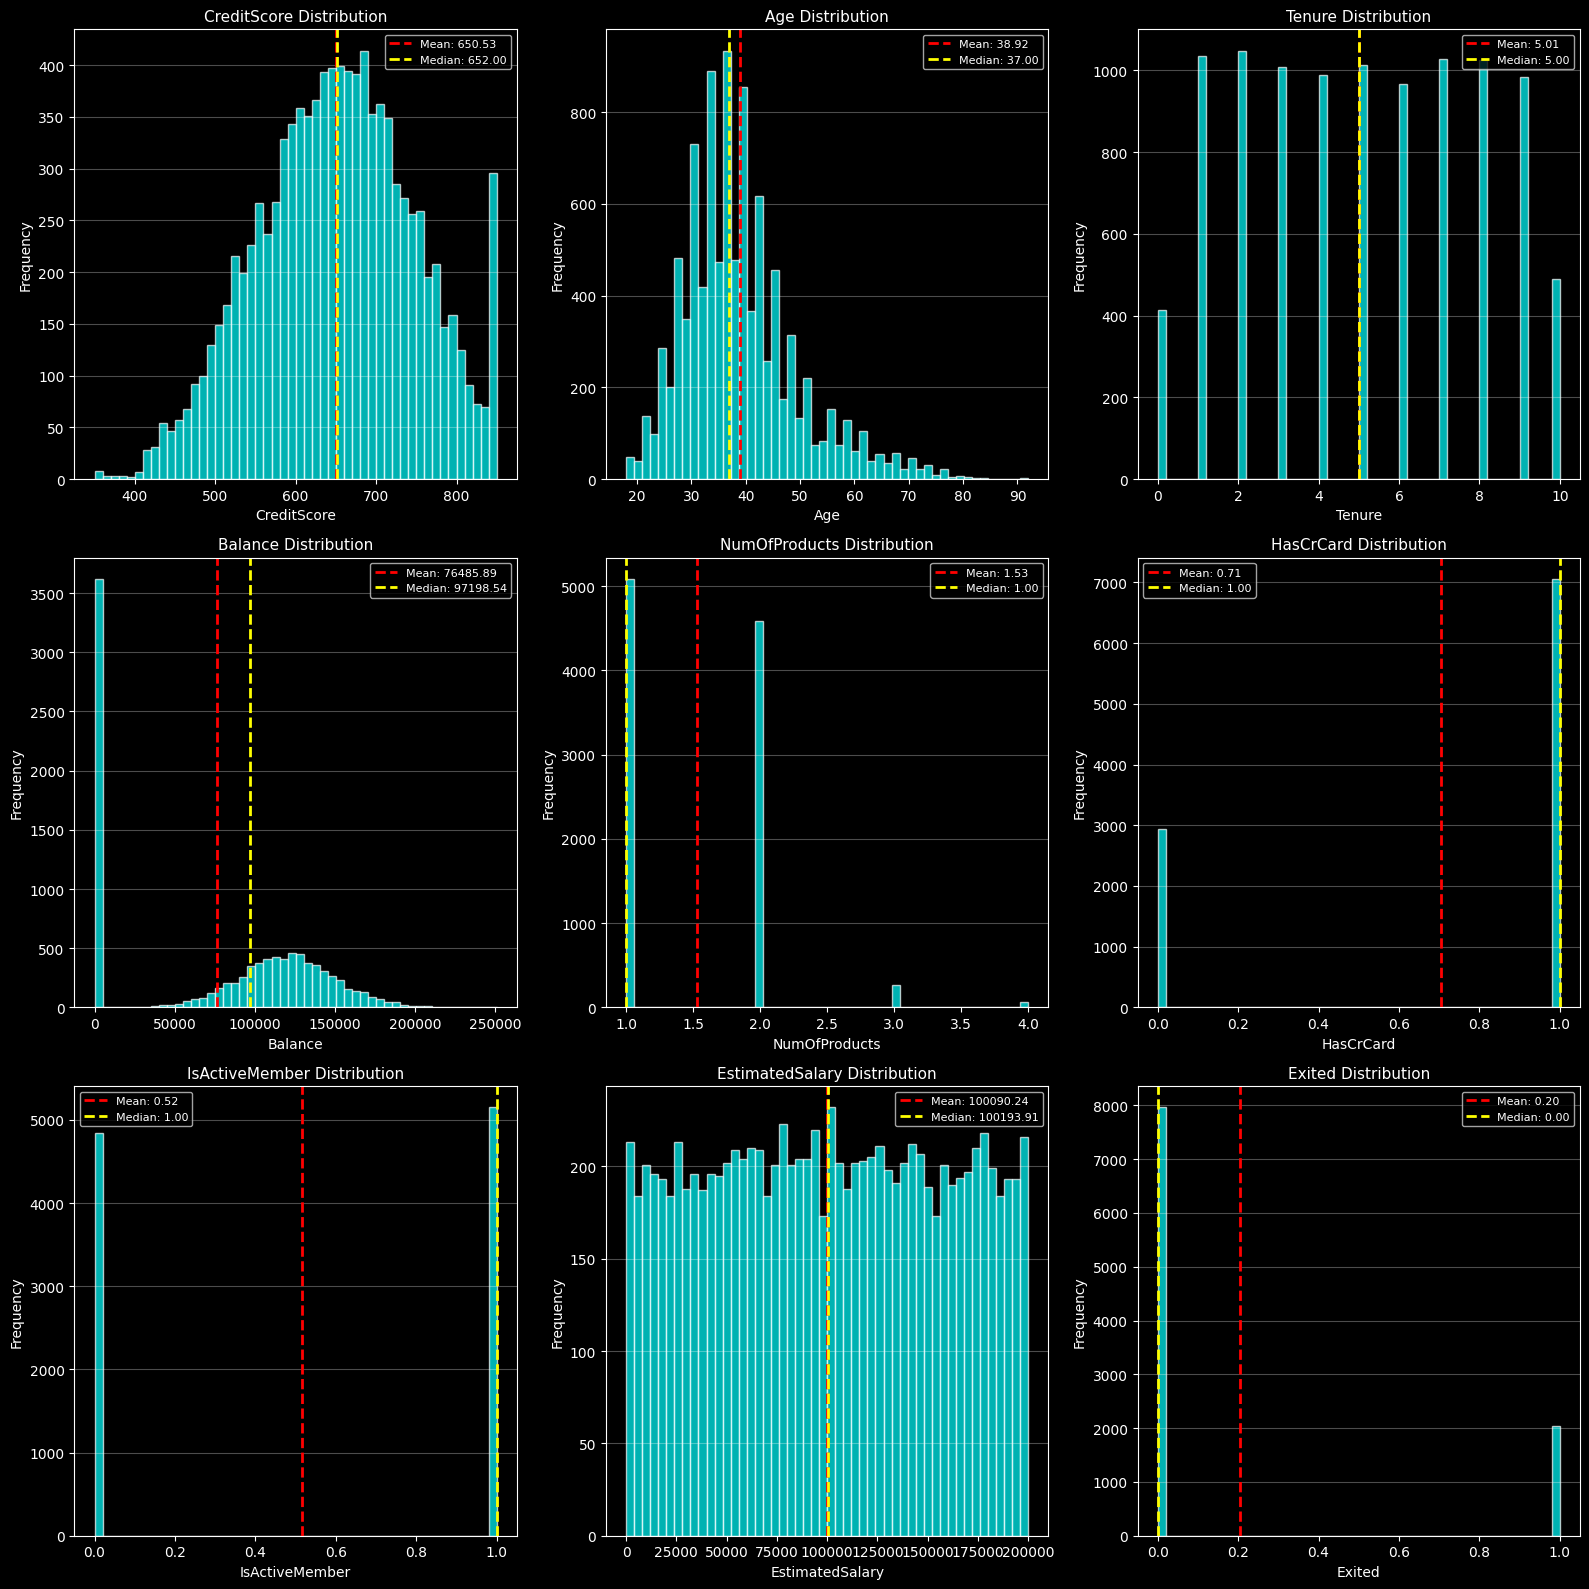

In [14]:
# Feature distributions
fig, axes = plt.subplots(3, 3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(num_col):
    axes[i].hist(df[col], bins=50, alpha=0.7, color='cyan', edgecolor='white')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].set_title(f'{col} Distribution', fontsize=11)
    axes[i].grid(alpha=0.3, axis='y')

    # Add mean and median lines
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='yellow', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[i].legend(fontsize=8)


plt.tight_layout()
plt.show()


In [15]:
cat_col = df.select_dtypes(include = ["object"]).columns
print(f"Number of this feature = {len(cat_col)}")
print ("\n",cat_col)

Number of this feature = 2

 Index(['Geography', 'Gender'], dtype='object')


### Outlier Detection

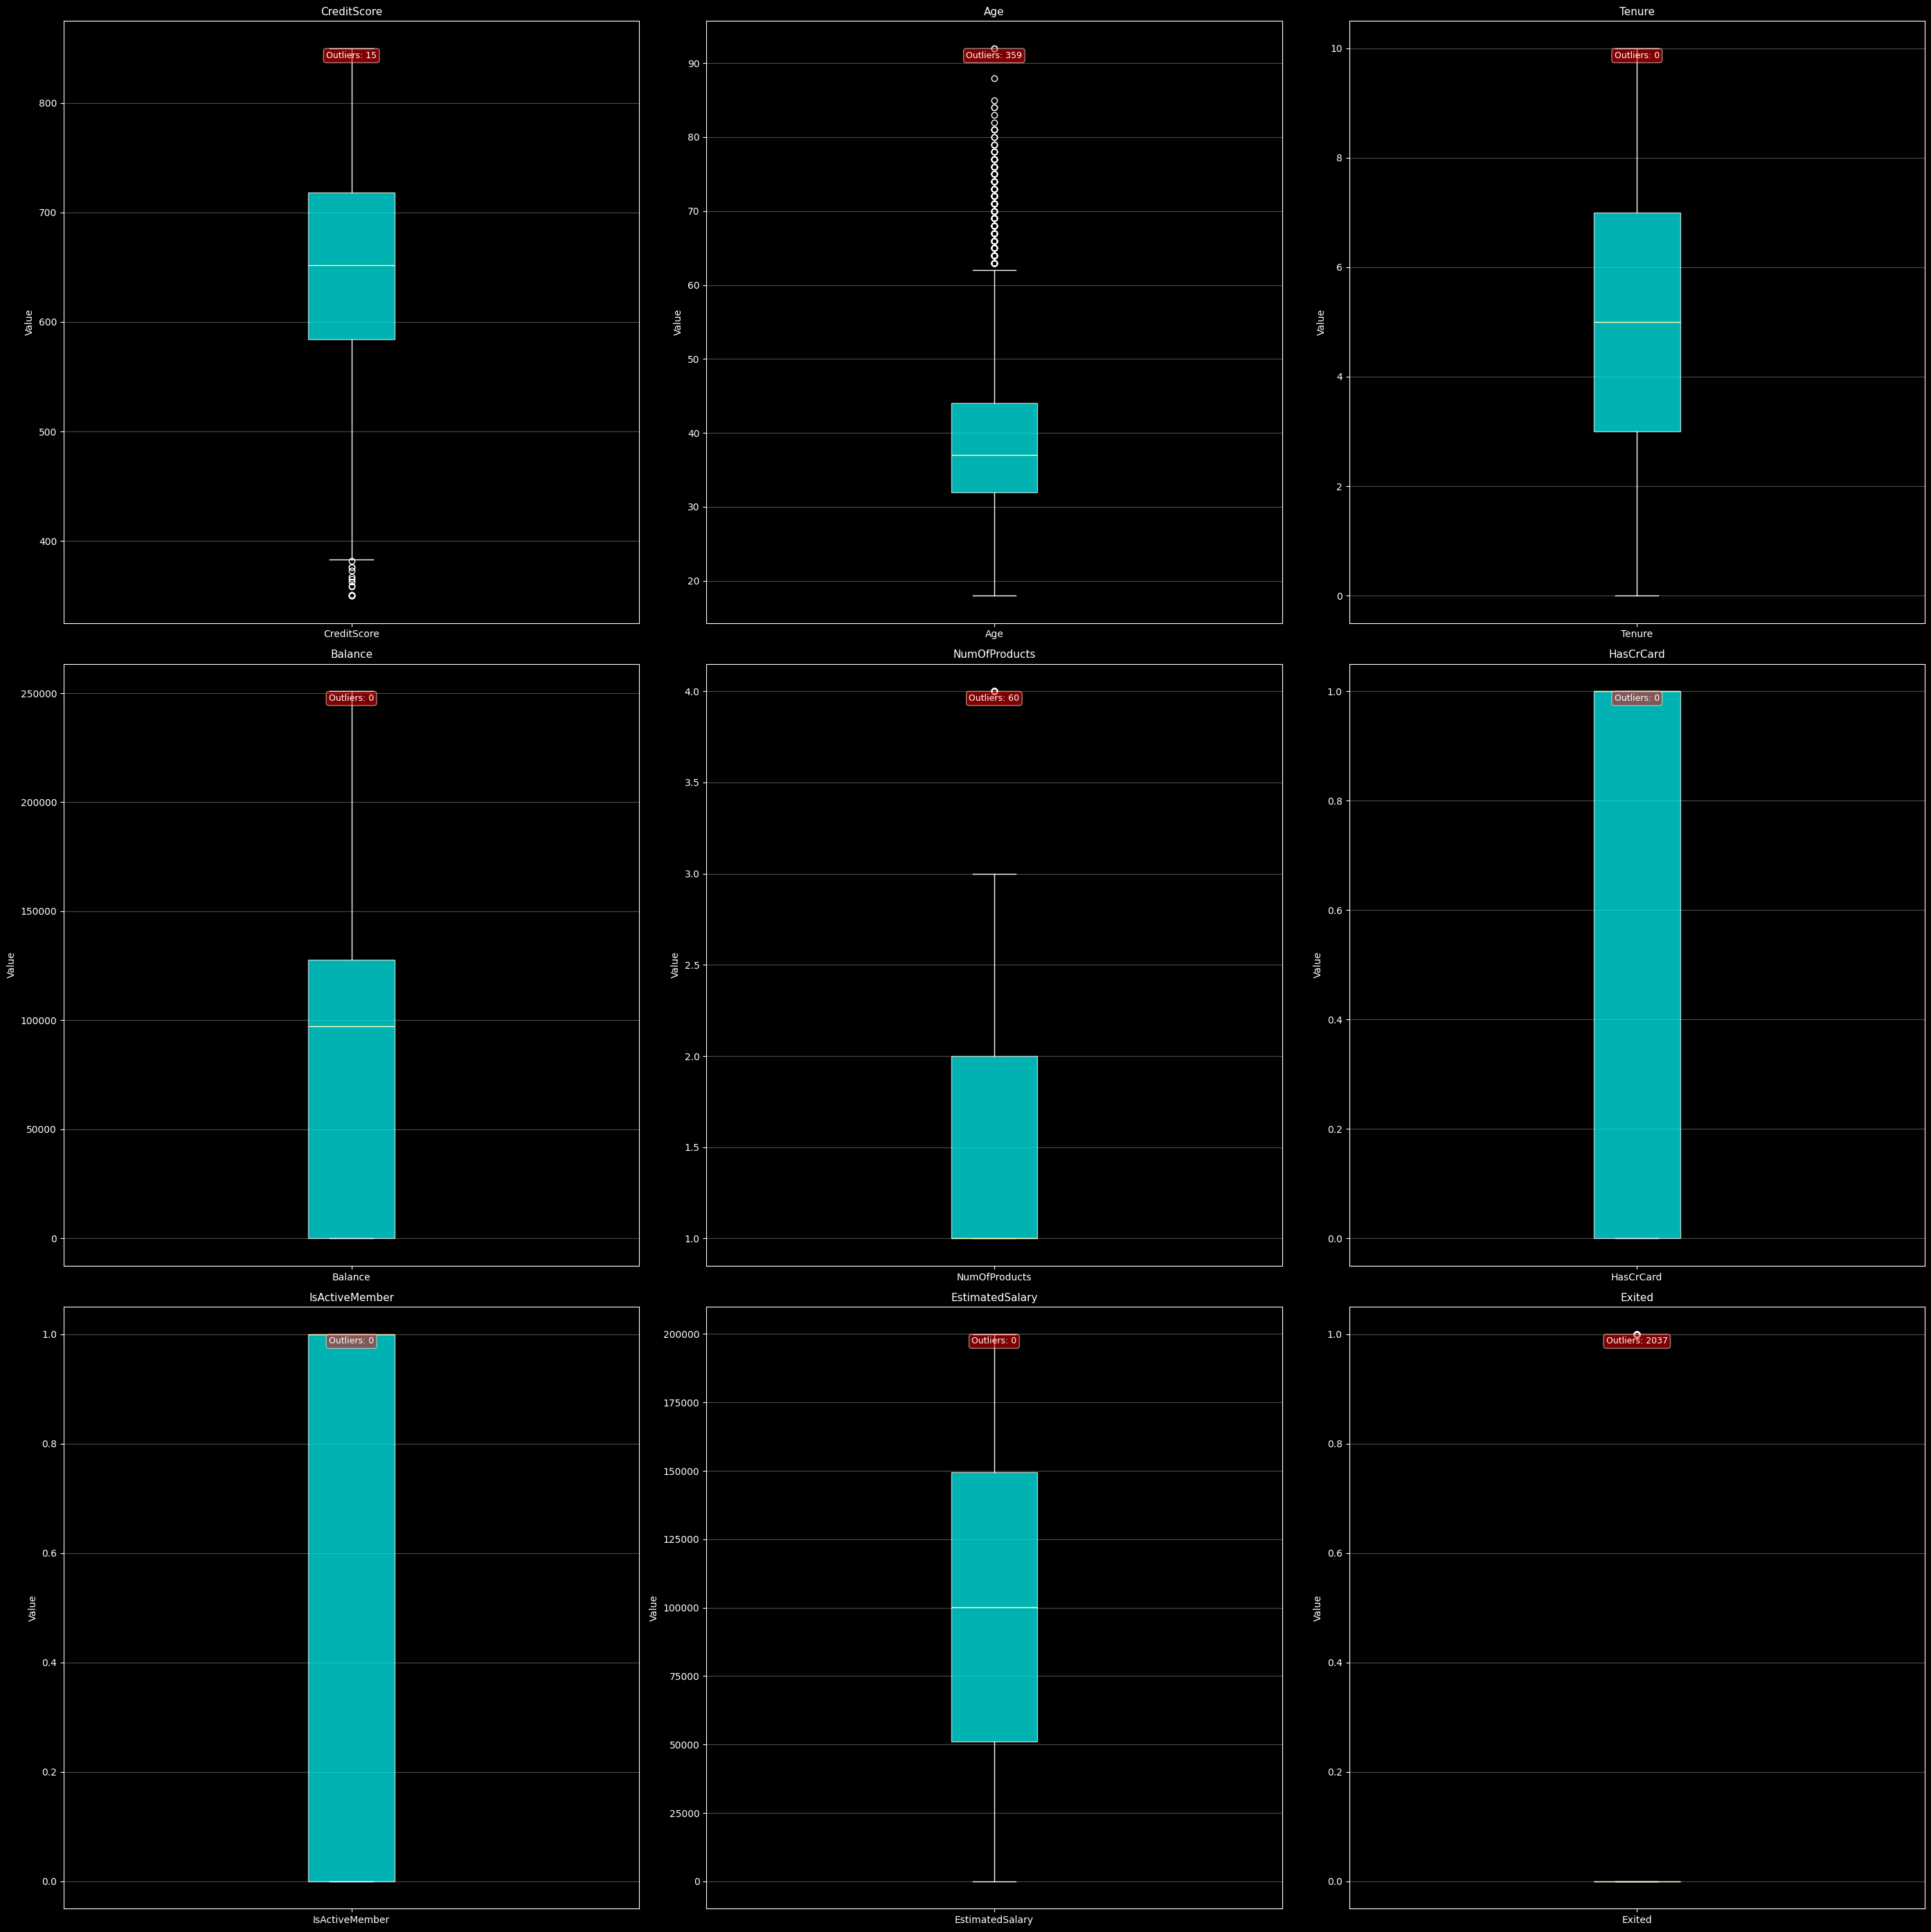

In [16]:
# Box plots for outlier detection
fig, axes = plt.subplots(3, 3, figsize=(28, 28))
axes = axes.flatten()

for i, col in enumerate(num_col):
    bp = axes[i].boxplot([df[col]], tick_labels=[col], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('cyan')
        patch.set_alpha(0.7)
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].grid(alpha=0.3, axis='y')

    # Count outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    axes[i].text(0.5, 0.95, f'Outliers: {outliers}',
                 transform=axes[i].transAxes, ha='center', va='top',
                 bbox=dict(boxstyle='round', facecolor='red', alpha=0.5), fontsize=9)

plt.tight_layout()
plt.show()


### Correlation Matrix - Way for mixed type of data

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 77.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 75.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 89.5 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninsta

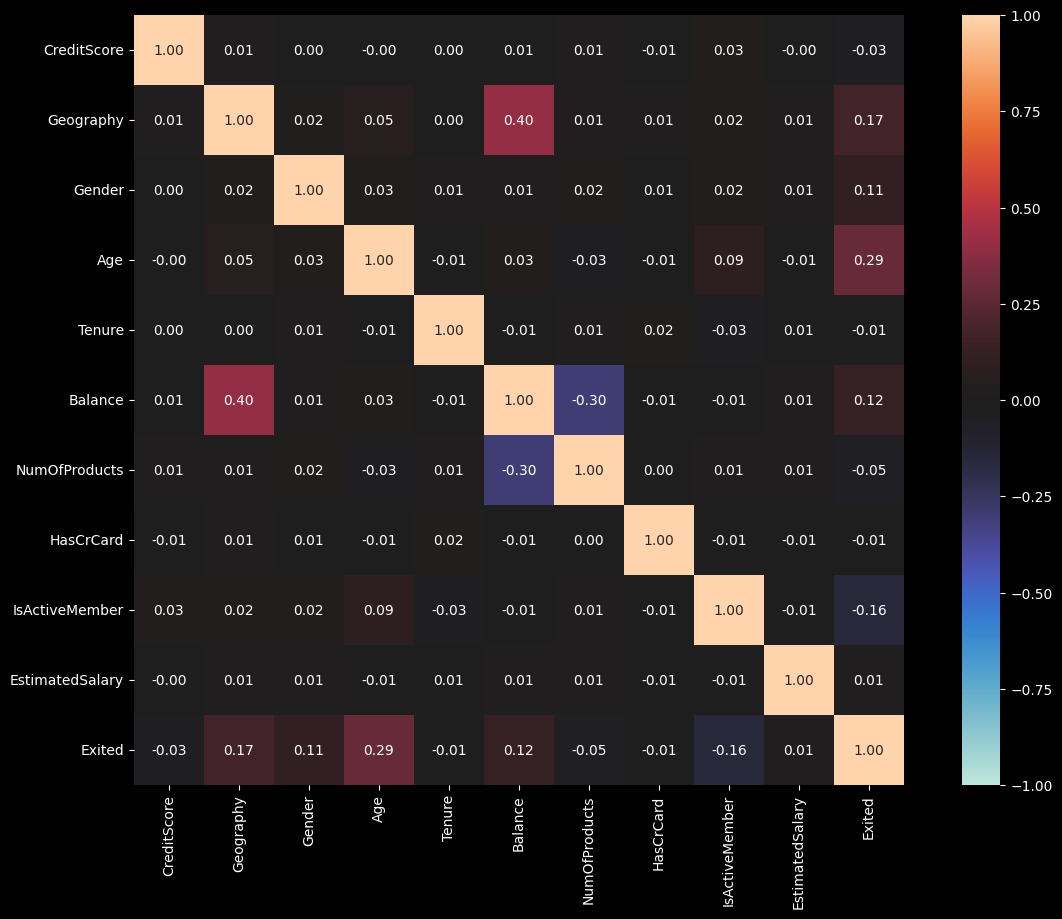

{'corr':                  CreditScore  Geography    Gender       Age    Tenure  \
 CreditScore         1.000000   0.008939  0.002857 -0.003965  0.000842   
 Geography           0.008939   1.000000  0.022178  0.049154  0.003942   
 Gender              0.002857   0.022178  1.000000  0.027544  0.014733   
 Age                -0.003965   0.049154  0.027544  1.000000 -0.009997   
 Tenure              0.000842   0.003942  0.014733 -0.009997  1.000000   
 Balance             0.006268   0.401114  0.012087  0.028308 -0.012254   
 NumOfProducts       0.012238   0.011981  0.021859 -0.030680  0.013444   
 HasCrCard          -0.005458   0.014951  0.005766 -0.011721  0.022583   
 IsActiveMember      0.025651   0.023032  0.022544  0.085472 -0.028362   
 EstimatedSalary    -0.001384   0.010797  0.008112 -0.007201  0.007784   
 Exited             -0.027094   0.173567  0.106512  0.285323 -0.014001   
 
                   Balance  NumOfProducts  HasCrCard  IsActiveMember  \
 CreditScore      0.006268    

In [17]:
!pip install dython
from dython.nominal import associations

associations(df, figsize=(15, 10))



# 4.Data Preprocessing

### Encoded Categorical Features

In [18]:
cat_col = df.select_dtypes(include=["object"]).columns

encoders = {}
for col in cat_col:
    le = LabelEncoder()
    combined = pd.concat([df[col]], axis=0)
    le.fit(combined)

    df[col] = le.transform(df[col])

    encoders[col] = le

print(f"Encoded {len(cat_col)} categorical columns: {list(cat_col)}")
df.head()

Encoded 2 categorical columns: ['Geography', 'Gender']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


### Scaling

In [19]:
num_col = ['Age', 'Balance', 'HasCrCard', 'CreditScore', 'Tenure', 'NumOfProducts'
           , 'IsActiveMember', 'EstimatedSalary']

scaler = StandardScaler()
df[num_col] = scaler.fit_transform(df[num_col])

df[num_col].describe().T


,count,mean,std,min,25%,50%,75%,max
Age,10000.0,2.318146e-16,1.00005,-1.994969,-0.660018,-0.183251,0.484225,5.061197
Balance,10000.0,-6.252776e-17,1.00005,-1.225848,-1.225848,0.331964,0.819920,2.795323
HasCrCard,10000.0,-5.258016e-17,1.00005,-1.547768,-1.547768,0.646092,0.646092,0.646092
CreditScore,10000.0,-4.824585e-16,1.00005,-3.109504,-0.688359,0.015222,0.698109,2.063884
Tenure,10000.0,-1.078249e-16,1.00005,-1.733315,-0.695982,-0.004426,0.687130,1.724464
NumOfProducts,10000.0,1.634248e-17,1.00005,-0.911583,-0.911583,-0.911583,0.807737,4.246377
IsActiveMember,10000.0,-7.389644e-17,1.00005,-1.030670,-1.030670,0.970243,0.970243,0.970243
EstimatedSalary,10000.0,-2.877698e-17,1.00005,-1.740268,-0.853594,0.001803,0.857243,1.737200


### Split Data

In [20]:
X = df.drop(columns=['Exited'])
y = df['Exited']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# splitting used for Early Stopping
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train, test_size=0.2, random_state=42, stratify=y_train)


X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

scaler = StandardScaler()
X_train[num_col] = scaler.fit_transform(X_train[num_col])
X_val[num_col]   = scaler.transform(X_val[num_col])
X_test[num_col]  = scaler.transform(X_test[num_col])

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X_train: (6400, 10), X_val: (1600, 10), X_test: (2000, 10)


# Build Deep Neural Network

### Parameters

In [21]:
batch_size = 128
hidden_units = 64
dropout = 0.40

### Model

In [22]:
model = Sequential()

model.add(Dense(hidden_units, input_dim = X_train.shape[1]))
model.add(Activation('relu'))
model.add(Dropout(dropout))


model.add(Dense(hidden_units))
model.add(Activation('relu'))
model.add(Dropout(dropout))


model.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-08-14 13:17:51.634063: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Summary

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,929 (19.25 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 0 (0.00 B)

### Visualizaion

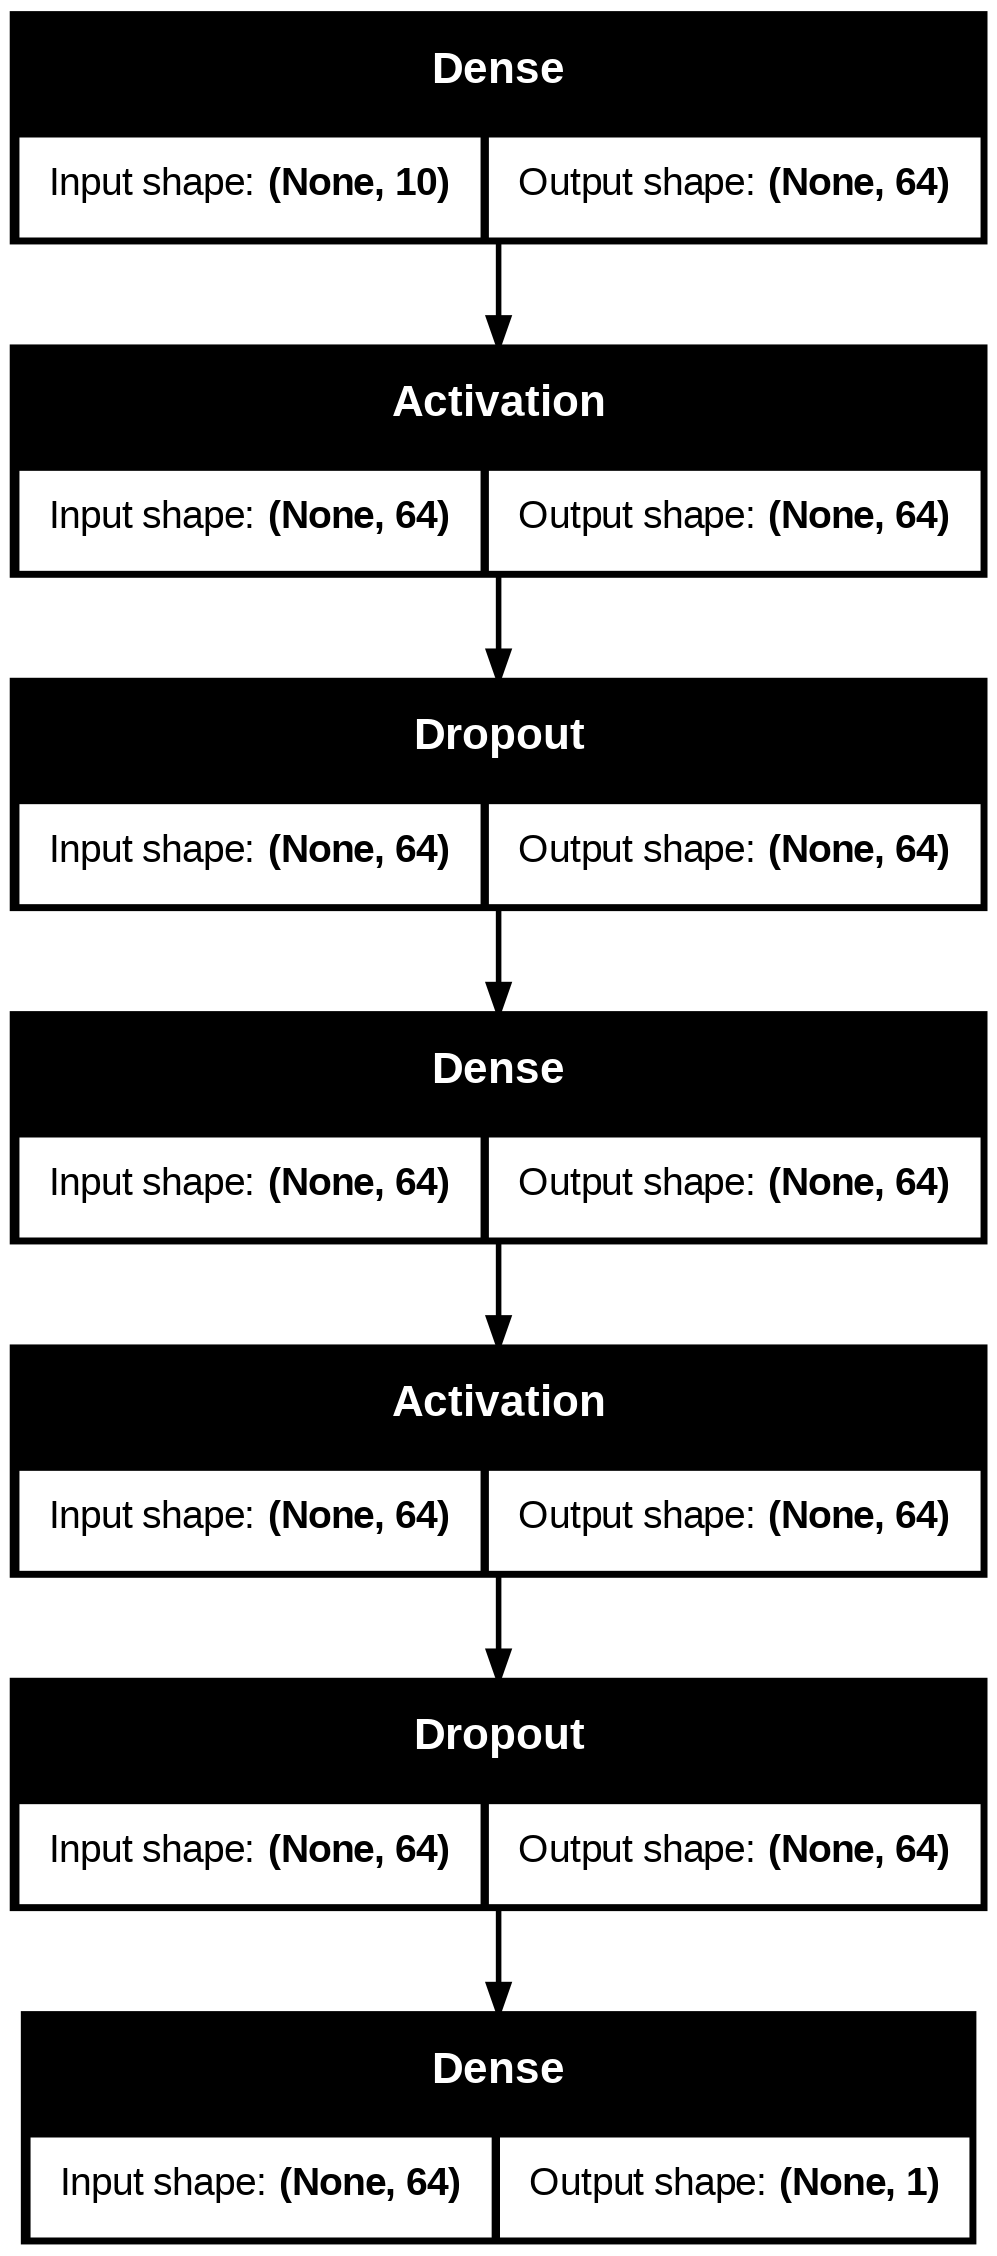

In [24]:
plot_model(model, show_shapes=True)

### Compiling

In [25]:
import tensorflow as tf

model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy",tf.keras.metrics.AUC(name='auc')])

### Training Model

In [26]:
from sklearn.utils.class_weight import compute_class_weight
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = model.fit(X_train, y_train,validation_data=(X_val, y_val),epochs=100,batch_size=batch_size,class_weight=class_weight_dict,
                    callbacks=[early_stop, reduce_lr],verbose=1)

Class weights: {0: np.float64(0.6279434850863422), 1: np.float64(2.4539877300613497)}
Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5941 - auc: 0.6551 - loss: 0.6550 - val_accuracy: 0.6944 - val_auc: 0.7526 - val_loss: 0.5897 - learning_rate: 0.0010
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6617 - auc: 0.7234 - loss: 0.6147 - val_accuracy: 0.6787 - val_auc: 0.7637 - val_loss: 0.5970 - learning_rate: 0.0010
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6911 - auc: 0.7464 - loss: 0.5980 - val_accuracy: 0.6831 - val_auc: 0.7731 - val_loss: 0.5992 - learning_rate: 0.0010
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6897 - auc: 0.7576 - loss: 0.5878 - val_accuracy: 0.7188 - val_auc: 0.7810 - val_loss: 0.5587 - learning_rate: 0.0010
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7033 - auc: 0.7714 - loss: 0.5729 - val_accuracy: 0.7406 - val_auc: 0.7899 - val_loss: 0.5276 - learning_rate: 0.001

### Training Visualization

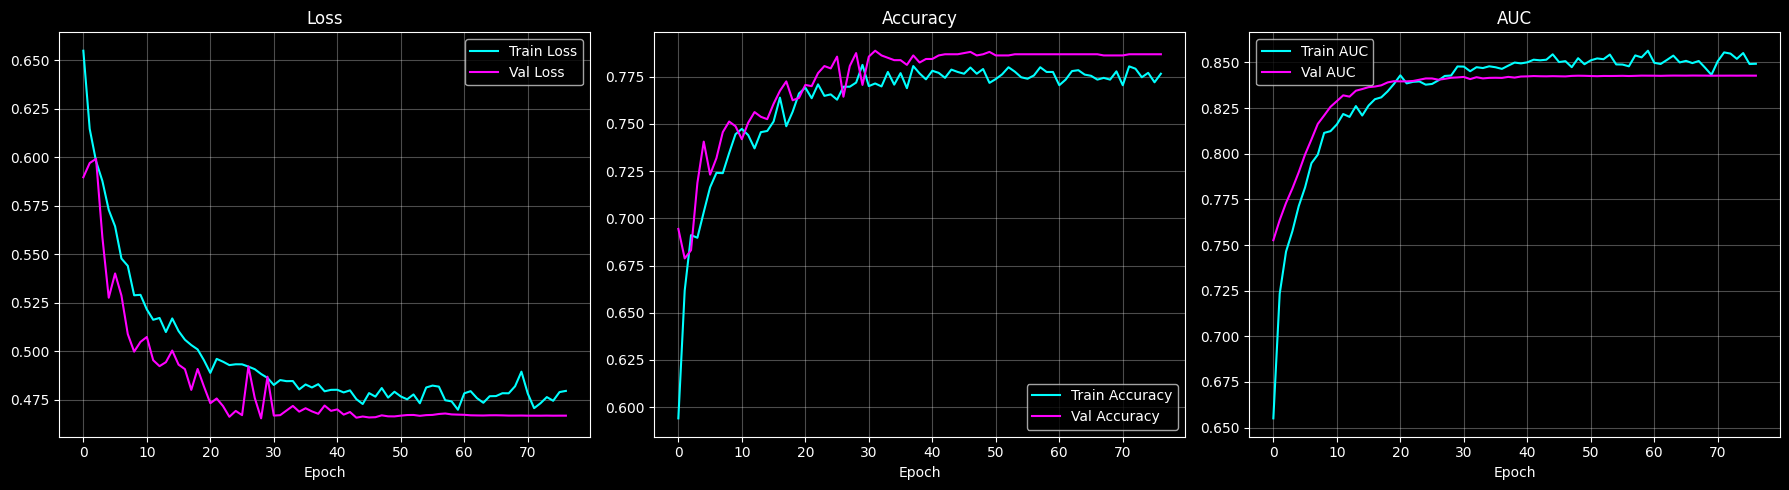

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='cyan')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='magenta')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='cyan')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='magenta')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history.history['auc'], label='Train AUC', color='cyan')
axes[2].plot(history.history['val_auc'], label='Val AUC', color='magenta')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Evaluate Model

In [28]:
y_pred_proba = model.predict(X_test).ravel()

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.nanargmax(f1_scores[:-1])  # last point has no corresponding threshold
best_threshold = thresholds[best_idx]
print(f"Best F1 threshold (chosen from PR curve): {best_threshold:.3f}")

y_pred = (y_pred_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

target_names = ['Retained', 'Exited']

print(f"Accuracy : {acc:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print("\n", classification_report(y_test, y_pred, target_names=target_names))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Best F1 threshold (chosen from PR curve): 0.570
Accuracy : 0.7890
F1-score : 0.5887
ROC-AUC  : 0.8546

               precision    recall  f1-score   support

    Retained       0.92      0.80      0.86      1593
      Exited       0.49      0.74      0.59       407

    accuracy                           0.79      2000
   macro avg       0.71      0.77      0.72      2000
weighted avg       0.84      0.79      0.80      2000



### Confusion Matrix

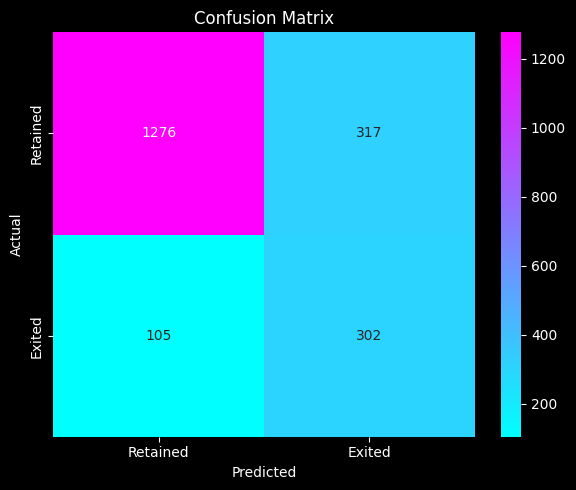

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='cool',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


### Roc Curve

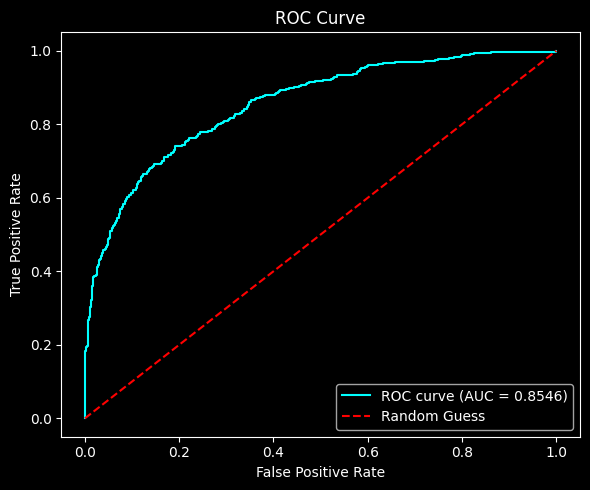

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='cyan', label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()
plt.tight_layout()
plt.show()
